# Notebook 1: Data Exploration

Understand the raw SBA loan dataset: shape, columns, distributions, and data-quality issues.

Outputs of this notebook:
- Column reference
- Missing-data summary
- Target class balance
- Initial signal check on candidate predictors

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)

## 1. Load the data

`SBAnational.csv` must be downloaded from Kaggle and placed in `/data/`.

In [2]:
df = pd.read_csv('../data/SBAnational.csv', low_memory=False)

print(f'Shape: {df.shape}')
print(f'Rows: {df.shape[0]:,}')
print(f'Columns: {df.shape[1]}')
df.head()

Shape: (899164, 27)
Rows: 899,164
Columns: 27


,LoanNr_ChkDgt,Name,City,State,Zip,Bank,BankState,NAICS,ApprovalDate,ApprovalFY,Term,NoEmp,NewExist,CreateJob,RetainedJob,FranchiseCode,UrbanRural,RevLineCr,LowDoc,ChgOffDate,DisbursementDate,DisbursementGross,BalanceGross,MIS_Status,ChgOffPrinGr,GrAppv,SBA_Appv
0,1000014003,ABC HOBBYCRAFT,EVANSVILLE,IN,47711,FIFTH THIRD BANK,OH,451120,28-Feb-97,1997,84,4,2.00,0,0,1,0,N,Y,NaN,28-Feb-99,"$60,000.00",$0.00,P I F,$0.00,"$60,000.00","$48,000.00"
1,1000024006,LANDMARK BAR & GRILLE (THE),NEW PARIS,IN,46526,1ST SOURCE BANK,IN,722410,28-Feb-97,1997,60,2,2.00,0,0,1,0,N,Y,NaN,31-May-97,"$40,000.00",$0.00,P I F,$0.00,"$40,000.00","$32,000.00"
2,1000034009,"WHITLOCK DDS, TODD M.",BLOOMINGTON,IN,47401,GRANT COUNTY STATE BANK,IN,621210,28-Feb-97,1997,180,7,1.00,0,0,1,0,N,N,NaN,31-Dec-97,"$287,000.00",$0.00,P I F,$0.00,"$287,000.00","$215,250.00"
3,1000044001,"BIG BUCKS PAWN & JEWELRY, LLC",BROKEN ARROW,OK,74012,1ST NATL BK & TR CO OF BROKEN,OK,0,28-Feb-97,1997,60,2,1.00,0,0,1,0,N,Y,NaN,30-Jun-97,"$35,000.00",$0.00,P I F,$0.00,"$35,000.00","$28,000.00"
4,1000054004,"ANASTASIA CONFECTIONS, INC.",ORLANDO,FL,32801,FLORIDA BUS. DEVEL CORP,FL,0,28-Feb-97,1997,240,14,1.00,7,7,1,0,N,N,NaN,14-May-97,"$229,000.00",$0.00,P I F,$0.00,"$229,000.00","$229,000.00"


## 2. Column reference

| Column | Description |
|--------|-------------|
| `LoanNr_ChkDgt` | Unique loan identifier |
| `Name` | Business name |
| `City`, `State` | Business location |
| `Zip` | ZIP code |
| `Bank` | Lending bank |
| `BankState` | Bank state |
| `NAICS` | Industry code (first 2 digits = sector) |
| `ApprovalDate` | When loan was approved |
| `ApprovalFY` | Fiscal year of approval |
| `Term` | Loan term in months |
| `NoEmp` | Number of employees |
| `NewExist` | 1 = Existing business, 2 = New business |
| `CreateJob` | Jobs created |
| `RetainedJob` | Jobs retained |
| `FranchiseCode` | 0 = Not franchise, 1 = Franchise |
| `UrbanRural` | 1 = Urban, 2 = Rural, 0 = Undefined |
| `RevLineCr` | Revolving line of credit (Y/N) |
| `LowDoc` | Low documentation loan (Y/N) |
| `ChgOffDate` | Date charged off (defaulted) |
| `DisbursementDate` | Date funds disbursed |
| `DisbursementGross` | Total amount disbursed |
| `BalanceGross` | Remaining balance |
| `MIS_Status` | Target: CHGOFF = default, P I F = paid in full |
| `ChgOffPrinGr` | Amount charged off |
| `GrAppv` | Gross amount approved |
| `SBA_Appv` | SBA-guaranteed amount |

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 899164 entries, 0 to 899163
Data columns (total 27 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   LoanNr_ChkDgt      899164 non-null  int64  
 1   Name               899150 non-null  str    
 2   City               899134 non-null  str    
 3   State              899150 non-null  str    
 4   Zip                899164 non-null  int64  
 5   Bank               897605 non-null  str    
 6   BankState          897598 non-null  str    
 7   NAICS              899164 non-null  int64  
 8   ApprovalDate       899164 non-null  str    
 9   ApprovalFY         899164 non-null  str    
 10  Term               899164 non-null  int64  
 11  NoEmp              899164 non-null  int64  
 12  NewExist           899028 non-null  float64
 13  CreateJob          899164 non-null  int64  
 14  RetainedJob        899164 non-null  int64  
 15  FranchiseCode      899164 non-null  int64  
 16  UrbanRural   

## 3. Missing data

In [4]:
missing = pd.DataFrame({
    'missing_count': df.isnull().sum(),
    'missing_pct': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('missing_pct', ascending=False)

missing[missing['missing_count'] > 0]

,missing_count,missing_pct
ChgOffDate,736465,81.91
RevLineCr,4528,0.50
LowDoc,2582,0.29
DisbursementDate,2368,0.26
MIS_Status,1997,0.22
Bank,1559,0.17
BankState,1566,0.17
NewExist,136,0.02
Name,14,0.00
City,30,0.00


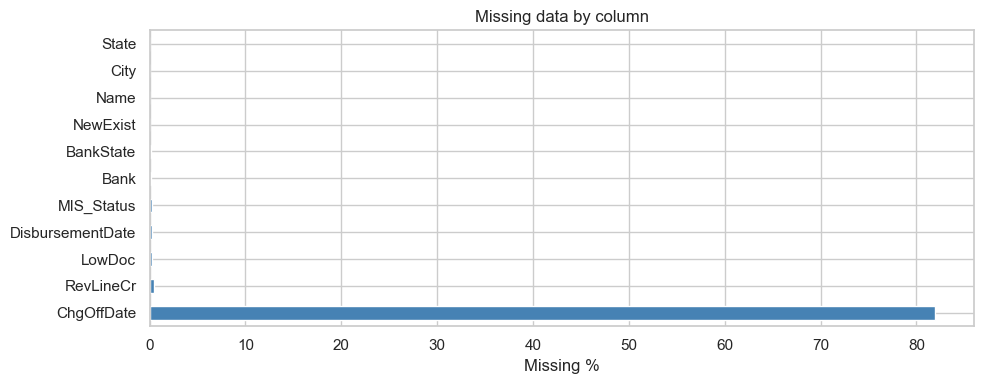

In [5]:
plt.figure(figsize=(10, 4))
missing[missing['missing_count'] > 0]['missing_pct'].plot(kind='barh', color='steelblue')
plt.xlabel('Missing %')
plt.title('Missing data by column')
plt.tight_layout()
plt.show()

## 4. Target variable: MIS_Status

`CHGOFF` = defaulted, `P I F` = paid in full.

In [6]:
print('Target value counts:')
print(df['MIS_Status'].value_counts())
print()
print('Target percentages:')
print(df['MIS_Status'].value_counts(normalize=True).mul(100).round(2))

Target value counts:
MIS_Status
P I F     739609
CHGOFF    157558
Name: count, dtype: int64

Target percentages:
MIS_Status
P I F    82.44
CHGOFF   17.56
Name: proportion, dtype: float64


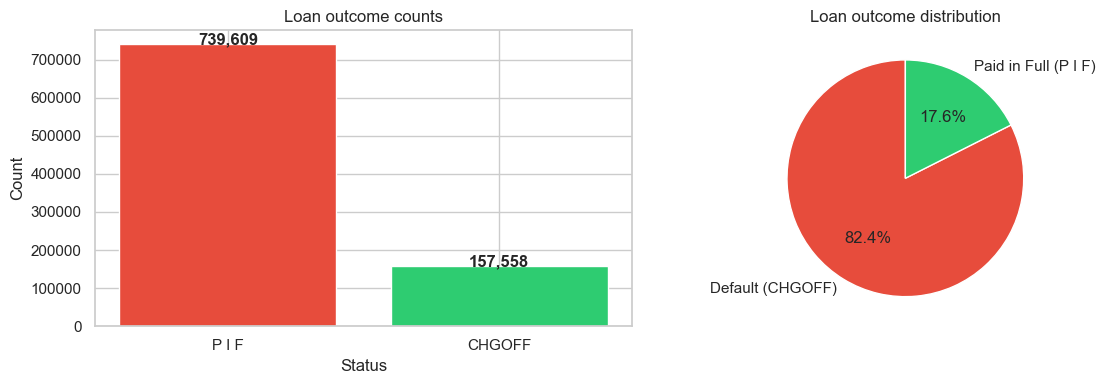

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['MIS_Status'].value_counts()
axes[0].bar(counts.index, counts.values, color=['#e74c3c', '#2ecc71'])
axes[0].set_title('Loan outcome counts')
axes[0].set_xlabel('Status')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=['Default (CHGOFF)', 'Paid in Full (P I F)'],
            autopct='%1.1f%%', colors=['#e74c3c', '#2ecc71'], startangle=90)
axes[1].set_title('Loan outcome distribution')

plt.tight_layout()
plt.show()

Defaults are the minority class; class imbalance is handled at training time via `scale_pos_weight`.

## 5. Numeric feature distributions

In [8]:
df.describe()

,LoanNr_ChkDgt,Zip,NAICS,Term,NoEmp,NewExist,CreateJob,RetainedJob,FranchiseCode,UrbanRural
count,899164.00,899164.00,899164.00,899164.00,899164.00,899028.00,899164.00,899164.00,899164.00,899164.00
mean,4772612310.59,53804.39,398660.95,110.77,11.41,1.28,8.43,10.80,2753.73,0.76
std,2538175037.45,31184.16,263318.31,78.86,74.11,0.45,236.69,237.12,12758.02,0.65
min,1000014003.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,2589757508.50,27587.00,235210.00,60.00,2.00,1.00,0.00,0.00,1.00,0.00
50%,4361439006.00,55410.00,445310.00,84.00,4.00,1.00,0.00,1.00,1.00,1.00
75%,6904626504.75,83704.00,561730.00,120.00,10.00,2.00,1.00,4.00,1.00,1.00
max,9996003010.00,99999.00,928120.00,569.00,9999.00,2.00,8800.00,9500.00,99999.00,2.00


In [9]:
# Dollar columns are stored as strings like '$1,234,567.00' and are cleaned in Notebook 2.
print('DisbursementGross sample values:')
print(df['DisbursementGross'].head(10))
print()
print('Data type:', df['DisbursementGross'].dtype)

DisbursementGross sample values:
0     $60,000.00 
1     $40,000.00 
2    $287,000.00 
3     $35,000.00 
4    $229,000.00 
5    $517,000.00 
6    $600,000.00 
7     $45,000.00 
8    $305,000.00 
9     $70,000.00 
Name: DisbursementGross, dtype: str

Data type: str


## 6. Loan term distribution

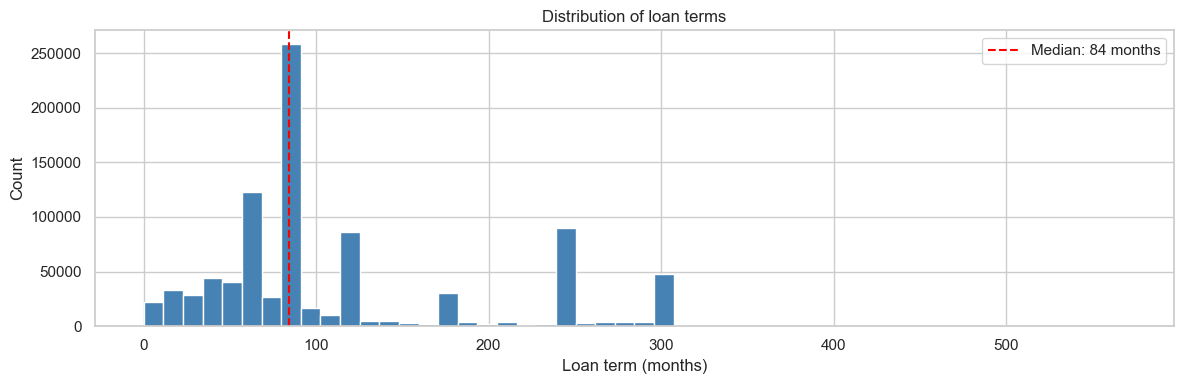

In [10]:
plt.figure(figsize=(12, 4))
df['Term'].dropna().hist(bins=50, color='steelblue', edgecolor='white')
plt.xlabel('Loan term (months)')
plt.ylabel('Count')
plt.title('Distribution of loan terms')
plt.axvline(df['Term'].median(), color='red', linestyle='--', label=f'Median: {df["Term"].median():.0f} months')
plt.legend()
plt.tight_layout()
plt.show()

## 7. Industry breakdown (NAICS)

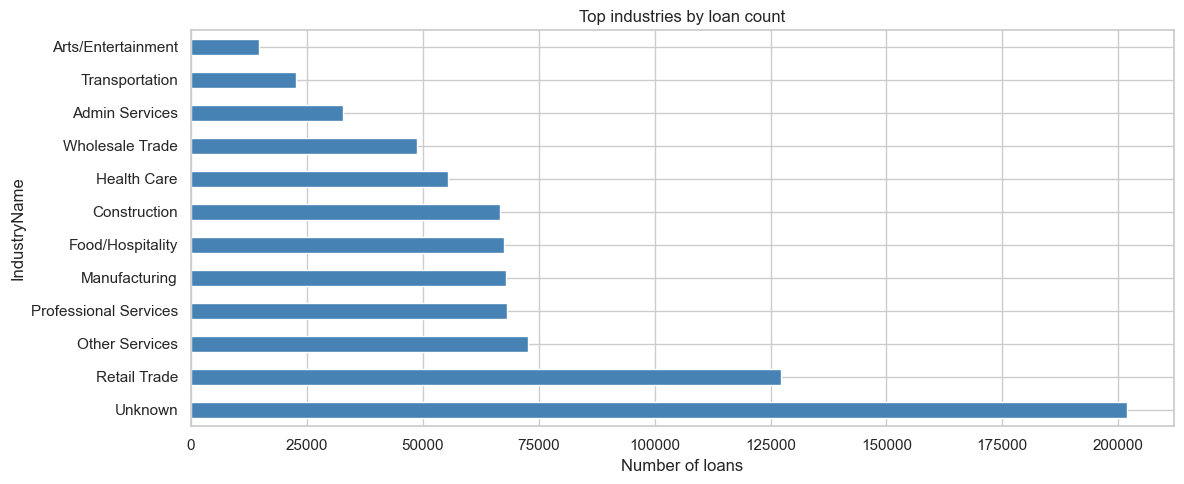

In [11]:
df['Industry'] = df['NAICS'].astype(str).str[:2]

naics_map = {
    '11': 'Agriculture', '21': 'Mining', '22': 'Utilities',
    '23': 'Construction', '31': 'Manufacturing', '32': 'Manufacturing',
    '33': 'Manufacturing', '42': 'Wholesale Trade', '44': 'Retail Trade',
    '45': 'Retail Trade', '48': 'Transportation', '49': 'Transportation',
    '51': 'Information', '52': 'Finance/Insurance', '53': 'Real Estate',
    '54': 'Professional Services', '55': 'Management', '56': 'Admin Services',
    '61': 'Education', '62': 'Health Care', '71': 'Arts/Entertainment',
    '72': 'Food/Hospitality', '81': 'Other Services', '92': 'Public Admin'
}

df['IndustryName'] = df['Industry'].map(naics_map).fillna('Unknown')

top_industries = df['IndustryName'].value_counts().head(12)

plt.figure(figsize=(12, 5))
top_industries.plot(kind='barh', color='steelblue')
plt.xlabel('Number of loans')
plt.title('Top industries by loan count')
plt.tight_layout()
plt.show()

## 8. Default rate by industry

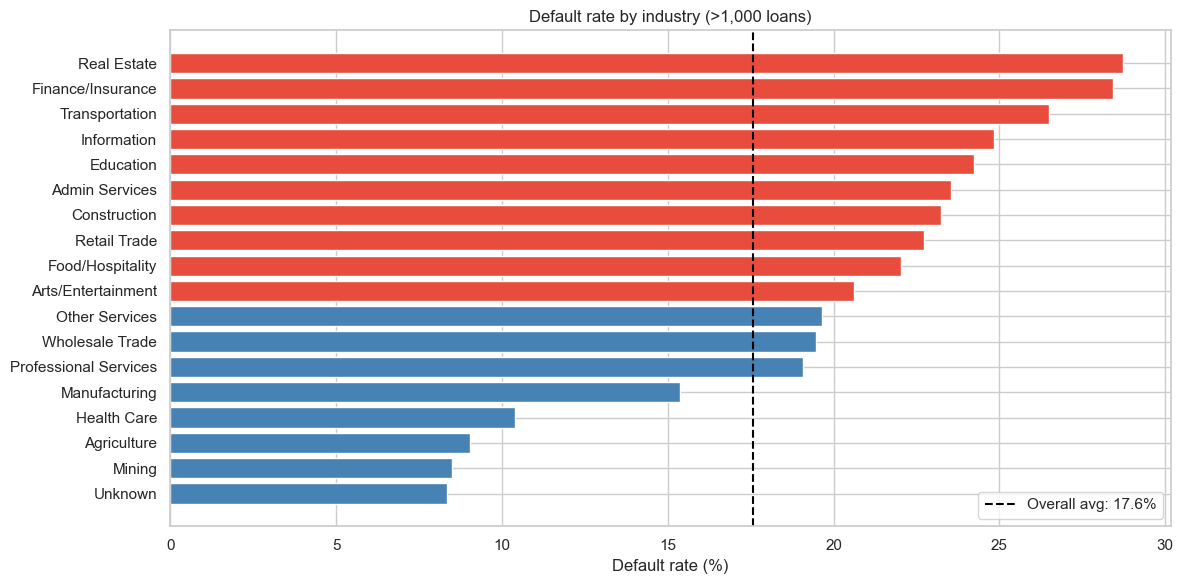

In [12]:
df_clean = df[df['MIS_Status'].isin(['CHGOFF', 'P I F'])].copy()
df_clean['Default'] = (df_clean['MIS_Status'] == 'CHGOFF').astype(int)

default_by_industry = df_clean.groupby('IndustryName')['Default'].agg(['mean', 'count'])
default_by_industry.columns = ['default_rate', 'loan_count']
default_by_industry = default_by_industry[default_by_industry['loan_count'] > 1000]
default_by_industry = default_by_industry.sort_values('default_rate', ascending=True)

plt.figure(figsize=(12, 6))
plt.barh(default_by_industry.index,
         default_by_industry['default_rate'] * 100,
         color=['#e74c3c' if x > 0.2 else 'steelblue'
                for x in default_by_industry['default_rate']])
plt.xlabel('Default rate (%)')
plt.title('Default rate by industry (>1,000 loans)')
plt.axvline(df_clean['Default'].mean() * 100, color='black', linestyle='--',
            label=f'Overall avg: {df_clean["Default"].mean()*100:.1f}%')
plt.legend()
plt.tight_layout()
plt.show()

## 9. Default rate by state

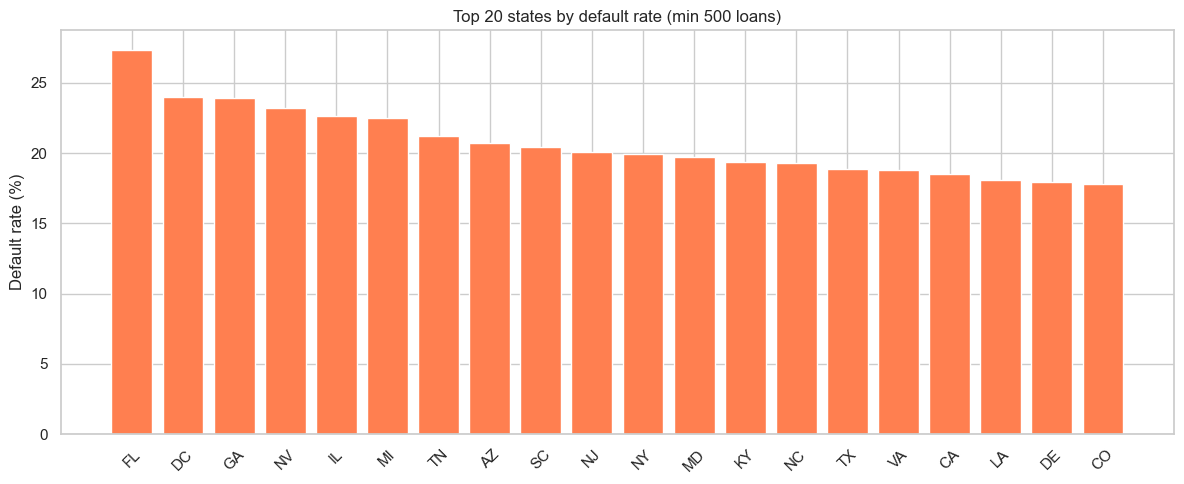

In [13]:
default_by_state = df_clean.groupby('State')['Default'].agg(['mean', 'count'])
default_by_state.columns = ['default_rate', 'loan_count']
default_by_state = default_by_state[default_by_state['loan_count'] > 500]
default_by_state = default_by_state.sort_values('default_rate', ascending=False).head(20)

plt.figure(figsize=(12, 5))
plt.bar(default_by_state.index, default_by_state['default_rate'] * 100, color='coral')
plt.ylabel('Default rate (%)')
plt.title('Top 20 states by default rate (min 500 loans)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 10. New vs existing business

                   mean   count
NewExist                       
Unknown            0.06    1028
Existing Business  0.17  643446
New Business       0.19  252559


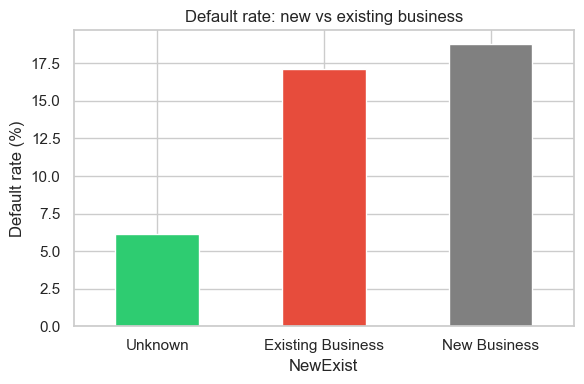

In [14]:
biz_type = df_clean.groupby('NewExist')['Default'].agg(['mean', 'count'])
biz_type.index = biz_type.index.map({1.0: 'Existing Business', 2.0: 'New Business', 0.0: 'Unknown'})
print(biz_type)

plt.figure(figsize=(6, 4))
biz_type['mean'].mul(100).plot(kind='bar', color=['#2ecc71', '#e74c3c', 'gray'])
plt.ylabel('Default rate (%)')
plt.title('Default rate: new vs existing business')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 11. Summary

Findings carried into Notebook 2:

- Class imbalance: default rate is well below 50%; will be addressed at training time.
- Dollar columns (`DisbursementGross`, `GrAppv`, `SBA_Appv`) are strings and require parsing.
- `ChgOffDate`, `ChgOffPrinGr`, and `BalanceGross` only exist for defaulted loans and must be dropped to avoid leakage.
- Rows with null `MIS_Status` are dropped.
- Candidate predictors with visible signal: industry (NAICS), loan term, new vs existing business, state, job counts, loan amount and SBA guarantee ratio.